In [105]:
import pandas as pd 

# Source of data: https://www.kaggle.com/datasets/jacobsharples/ontario-electricity-demand?resource=download
data_folder = './data/'

df1 = pd.read_csv(data_folder + 'ontario_electricity_demand.csv')
print(df1.head())
print(df1.shape)
print(df1.dtypes)

         date  hour  hourly_demand  hourly_average_price
0  2002-05-01     1       14137000                 22.97
1  2002-05-01     2       13872000                 23.27
2  2002-05-01     3       13820000                 24.54
3  2002-05-01     4       13744000                 15.17
4  2002-05-01     5       14224000                 23.59
(183432, 4)
date                     object
hour                      int64
hourly_demand             int64
hourly_average_price    float64
dtype: object


In [106]:
df1['date'] = pd.to_datetime(df1['date'])
df1['Year'] = df1['date'].dt.to_period('Y')
print(df1.head())

        date  hour  hourly_demand  hourly_average_price  Year
0 2002-05-01     1       14137000                 22.97  2002
1 2002-05-01     2       13872000                 23.27  2002
2 2002-05-01     3       13820000                 24.54  2002
3 2002-05-01     4       13744000                 15.17  2002
4 2002-05-01     5       14224000                 23.59  2002


In [107]:
yearly_demand = df1[(df1['Year'] != '2023') & (df1['Year'] != '2002')].groupby('Year').agg({
    'hourly_demand': ['mean', 'sum', 'max', 'min', 'std']
}).reset_index()

print(yearly_demand.head())

   Year hourly_demand                                                
                 mean           sum       max       min           std
0  2003  1.731957e+07  151719470000  24753000   2270000  2.617473e+06
1  2004  1.746778e+07  153436970000  24979000  11983000  2.528459e+06
2  2005  1.791913e+07  156971620000  26160000  11950000  2.744778e+06
3  2006  1.724364e+07  151054281000  27005000  11621000  2.557415e+06
4  2007  1.737507e+07  152205637000  25737000  11699000  2.637340e+06


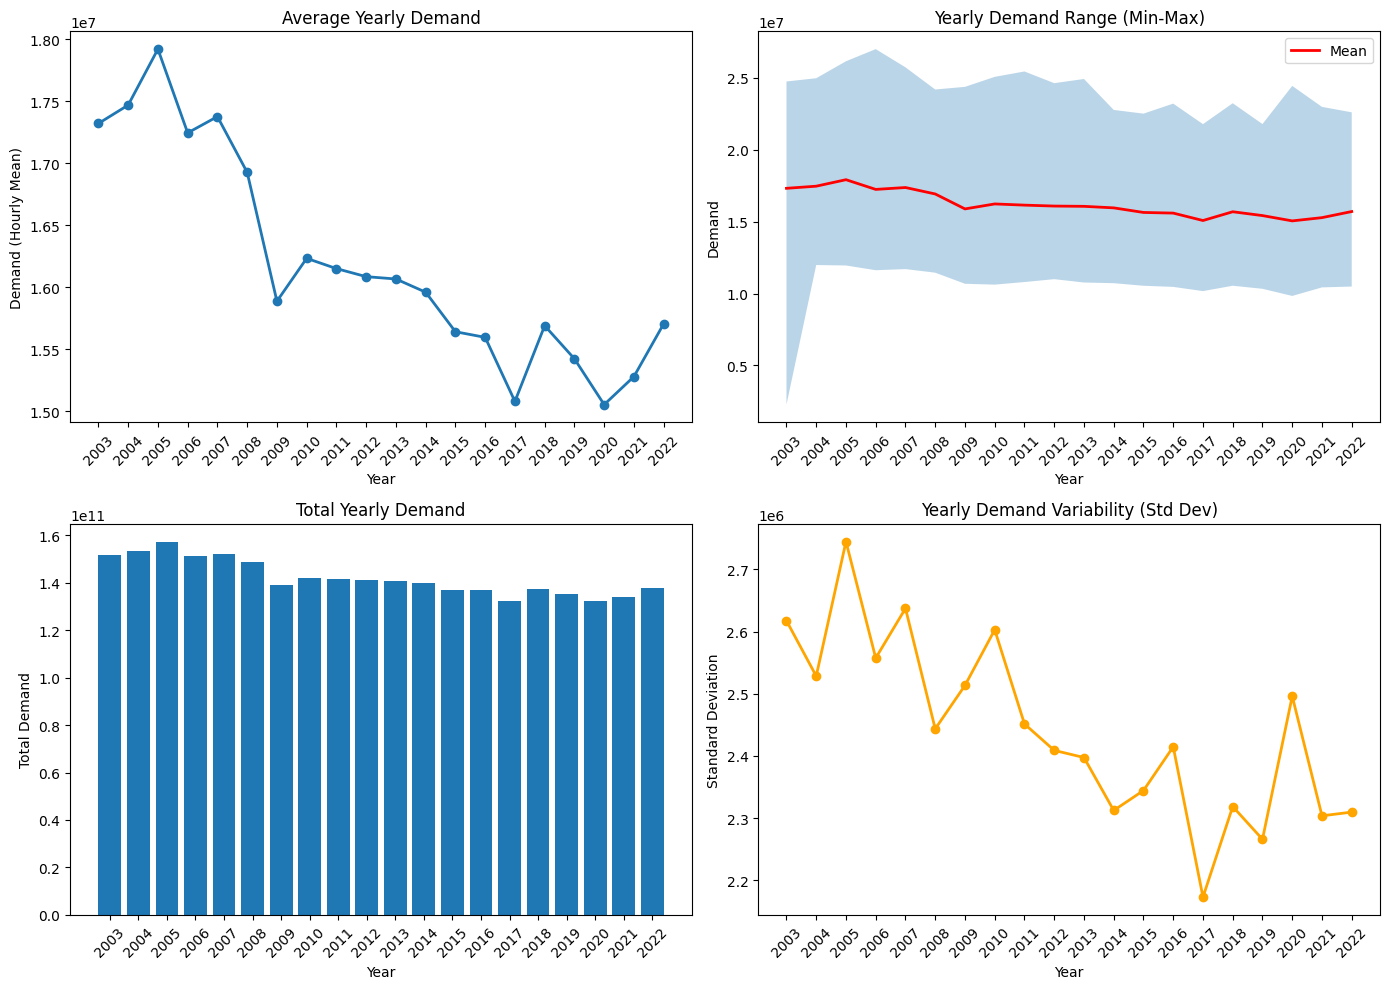

In [108]:
import matplotlib.pyplot as plt

# Flatten column names
yearly_demand.columns = ['Year', 'Mean', 'Sum', 'Max', 'Min', 'StdDev']
yearly_demand['Year'] = yearly_demand['Year'].astype(str)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

x = range(len(yearly_demand))

# Plot 1: Mean
axes[0, 0].plot(x, yearly_demand['Mean'], marker='o', linewidth=2)
axes[0, 0].set_title('Average Yearly Demand')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Demand (Hourly Mean)')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(yearly_demand['Year'], rotation=45)

# Plot 2: Range
axes[0, 1].fill_between(x, yearly_demand['Min'], yearly_demand['Max'], alpha=0.3)
axes[0, 1].plot(x, yearly_demand['Mean'], color='red', label='Mean', linewidth=2)
axes[0, 1].set_title('Yearly Demand Range (Min-Max)')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Demand')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(yearly_demand['Year'], rotation=45)
axes[0, 1].legend()

# Plot 3: Total
axes[1, 0].bar(x, yearly_demand['Sum'])
axes[1, 0].set_title('Total Yearly Demand')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Total Demand')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(yearly_demand['Year'], rotation=45)

# Plot 4: Std Dev
axes[1, 1].plot(x, yearly_demand['StdDev'], marker='o', color='orange', linewidth=2)
axes[1, 1].set_title('Yearly Demand Variability (Std Dev)')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Standard Deviation')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(yearly_demand['Year'], rotation=45)

plt.tight_layout()
plt.show()

In [109]:
# Load HourlyDemands data for 1994-2002
# Source of data: https://www.ieso.ca/en/Power-Data/Data-Directory?utm_source=chatgpt.com
df2 = pd.read_csv(data_folder + 'HourlyDemands_1994-2002.csv')
print(df2.head())
print(df2.shape)
print(df2.dtypes)

             DateTime  OntarioDemand
0  Jan 1 1994 12:00AM          14422
1  Jan 1 1994  1:00AM          13845
2  Jan 1 1994  2:00AM          13372
3  Jan 1 1994  3:00AM          13025
4  Jan 1 1994  4:00AM          12869
(72264, 2)
DateTime         object
OntarioDemand     int64
dtype: object


In [110]:

print(df2.columns)

df2_processed = df2.copy()

date_col = [col for col in df2_processed.columns if 'date' in col.lower()][0]
df2_processed[date_col] = pd.to_datetime(df2_processed[date_col])
df2_processed['Year'] = df2_processed[date_col].dt.to_period('Y')
print(df2_processed.head())

Index(['DateTime', 'OntarioDemand'], dtype='object')


C:\Users\arsen\AppData\Local\Temp\ipykernel_3352\4074226309.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df2_processed[date_col] = pd.to_datetime(df2_processed[date_col])


             DateTime  OntarioDemand  Year
0 1994-01-01 00:00:00          14422  1994
1 1994-01-01 01:00:00          13845  1994
2 1994-01-01 02:00:00          13372  1994
3 1994-01-01 03:00:00          13025  1994
4 1994-01-01 04:00:00          12869  1994


In [111]:
demand_col = [col for col in df2_processed.columns if 'demand' in col.lower()][0]

hourly_yearly_demand = df2_processed[df2_processed['Year'] != '2002'].groupby('Year').agg({
    demand_col: ['mean', 'sum', 'max', 'min', 'std']
}).reset_index()

print(hourly_yearly_demand.head())

   Year OntarioDemand                                      
                 mean        sum    max    min          std
0  1994  15550.044292  136218388  23856   9952  2603.420386
1  1995  15810.212557  138497462  22812  10207  2472.264542
2  1996  15797.793033  138767814  22072  10234  2377.090657
3  1997  15981.698402  139999678  22030  10515  2296.151979
4  1998  16174.941895  141692491  22403  11125  2278.246170


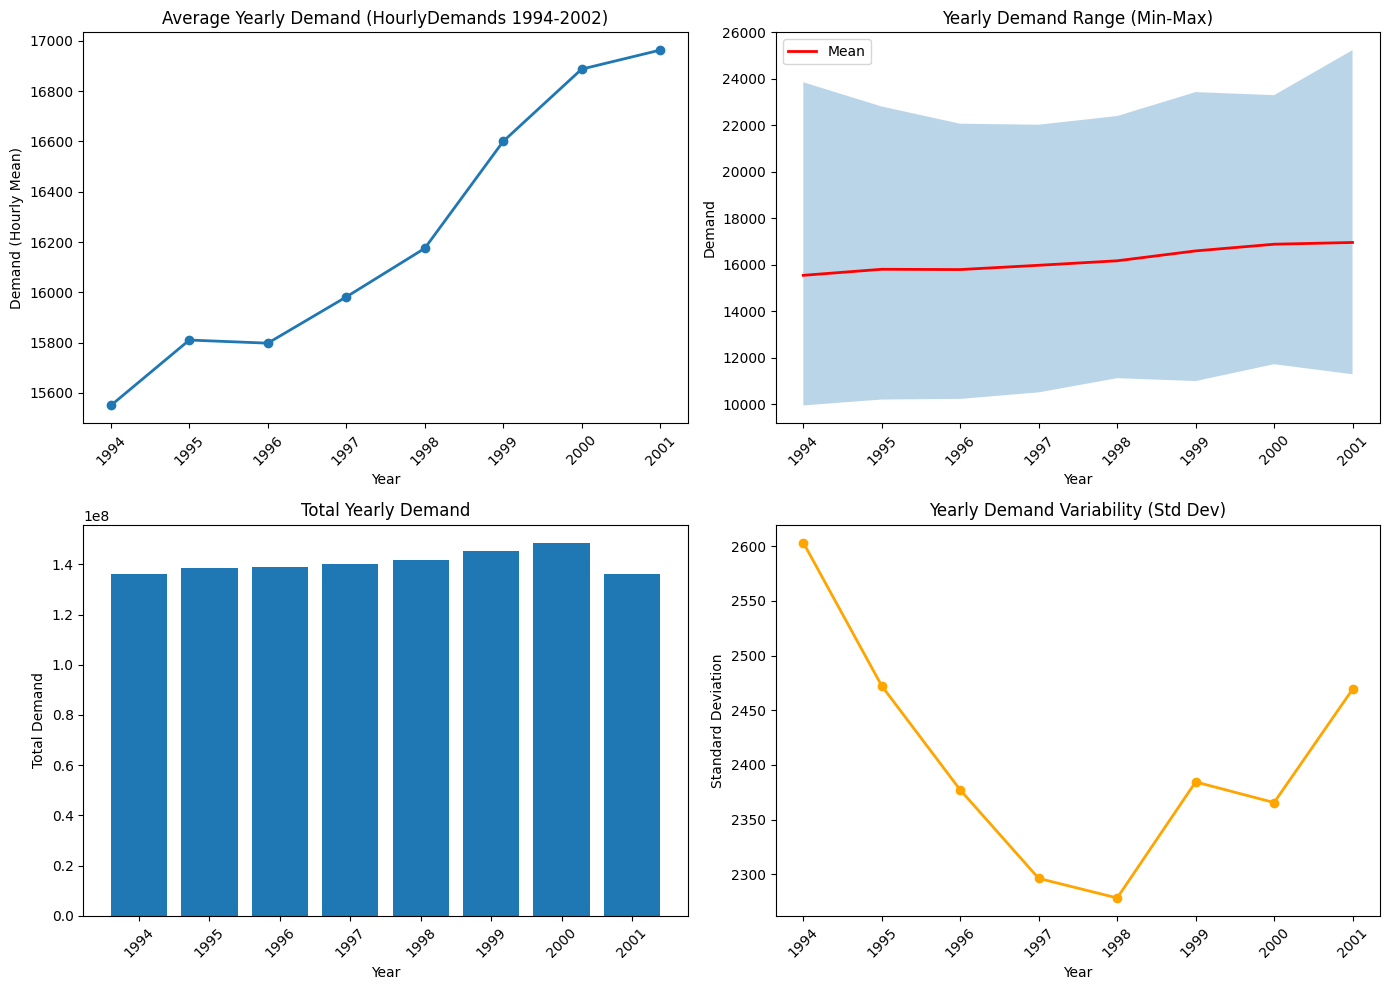

In [112]:

# Flatten column names
hourly_yearly_demand.columns = ['Year', 'Mean', 'Sum', 'Max', 'Min', 'StdDev']
hourly_yearly_demand['Year'] = hourly_yearly_demand['Year'].astype(str)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

x = range(len(hourly_yearly_demand))

# Plot 1: Mean
axes[0, 0].plot(x, hourly_yearly_demand['Mean'], marker='o', linewidth=2)
axes[0, 0].set_title('Average Yearly Demand (HourlyDemands 1994-2002)')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Demand (Hourly Mean)')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(hourly_yearly_demand['Year'], rotation=45)

# Plot 2: Range
axes[0, 1].fill_between(x, hourly_yearly_demand['Min'], hourly_yearly_demand['Max'], alpha=0.3)
axes[0, 1].plot(x, hourly_yearly_demand['Mean'], color='red', label='Mean', linewidth=2)
axes[0, 1].set_title('Yearly Demand Range (Min-Max)')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Demand')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(hourly_yearly_demand['Year'], rotation=45)
axes[0, 1].legend()

# Plot 3: Total
axes[1, 0].bar(x, hourly_yearly_demand['Sum'])
axes[1, 0].set_title('Total Yearly Demand')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Total Demand')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(hourly_yearly_demand['Year'], rotation=45)

# Plot 4: Std Dev
axes[1, 1].plot(x, hourly_yearly_demand['StdDev'], marker='o', color='orange', linewidth=2)
axes[1, 1].set_title('Yearly Demand Variability (Std Dev)')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Standard Deviation')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(hourly_yearly_demand['Year'], rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Yearly aggregation from combined hourly data
df_yearly = pd.read_csv('./data/Combined_Hourly_Demand_2002-2026.csv')
df_yearly['Date'] = pd.to_datetime(df_yearly['Date'])
df_yearly['Year'] = df_yearly['Date'].dt.to_period('Y')

# Find demand column
demand_col = [col for col in df_yearly.columns if 'demand' in col.lower()][0]

yearly_stats = df_yearly.groupby('Year').agg({
    demand_col: ['mean', 'sum', 'max', 'min', 'std']
}).reset_index()

yearly_stats.columns = ['Year', 'Mean', 'Sum', 'Max', 'Min', 'StdDev']
yearly_stats['Year'] = yearly_stats['Year'].astype(str)

print(yearly_stats)

FileNotFoundError: [Errno 2] No such file or directory: './data/Combined_Hourly_Data.csv'

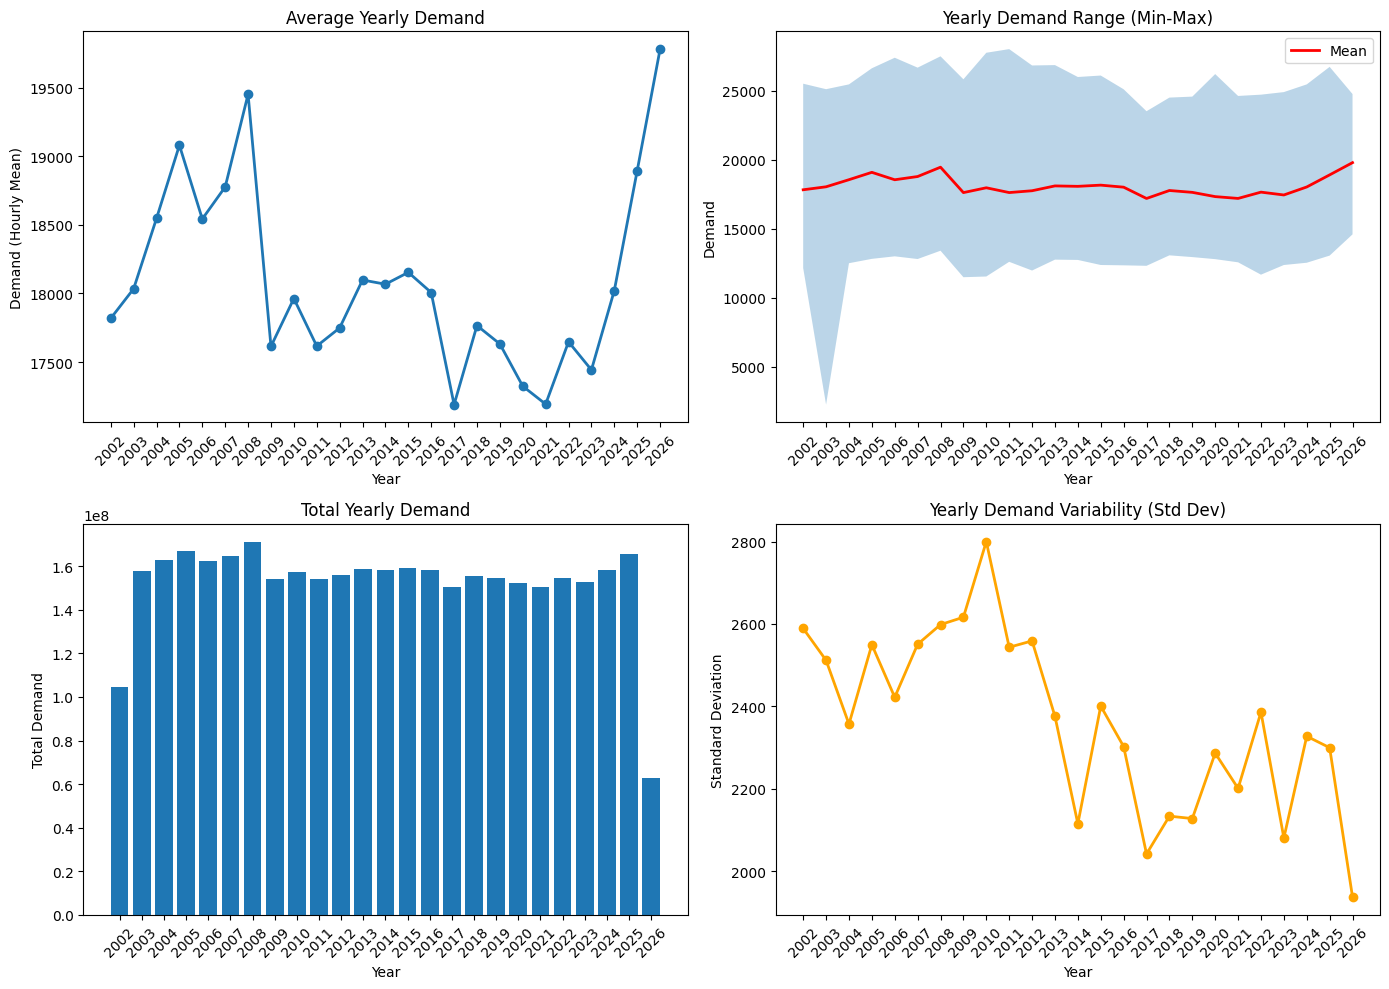

In [ ]:
# Visualize yearly demand
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

x = range(len(yearly_stats))

# Plot 1: Mean
axes[0, 0].plot(x, yearly_stats['Mean'], marker='o', linewidth=2)
axes[0, 0].set_title('Average Yearly Demand')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Demand (Hourly Mean)')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(yearly_stats['Year'], rotation=45)

# Plot 2: Range
axes[0, 1].fill_between(x, yearly_stats['Min'], yearly_stats['Max'], alpha=0.3)
axes[0, 1].plot(x, yearly_stats['Mean'], color='red', label='Mean', linewidth=2)
axes[0, 1].set_title('Yearly Demand Range (Min-Max)')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Demand')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(yearly_stats['Year'], rotation=45)
axes[0, 1].legend()

# Plot 3: Total
axes[1, 0].bar(x, yearly_stats['Sum'])
axes[1, 0].set_title('Total Yearly Demand')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Total Demand')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(yearly_stats['Year'], rotation=45)

# Plot 4: Std Dev
axes[1, 1].plot(x, yearly_stats['StdDev'], marker='o', color='orange', linewidth=2)
axes[1, 1].set_title('Yearly Demand Variability (Std Dev)')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Standard Deviation')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(yearly_stats['Year'], rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Check which column is being used and see year-by-year details
print(f"Demand column: {demand_col}")
print("\nDetailed yearly stats:")
print(yearly_stats)

# Check for outliers - which years have unusual values?
print("\nYear-over-year change:")
for i in range(1, len(yearly_stats)):
    prev_mean = yearly_stats.iloc[i-1]['Mean']
    curr_mean = yearly_stats.iloc[i]['Mean']
    pct_change = ((curr_mean - prev_mean) / prev_mean) * 100
    print(f"{yearly_stats.iloc[i-1]['Year']} → {yearly_stats.iloc[i]['Year']}: {pct_change:+.1f}%")

Demand column: Market Demand

Detailed yearly stats:
    Year          Mean        Sum    Max    Min       StdDev
0   2002  17818.642687  104773619  25496  12153  2589.100845
1   2003  18034.491324  157982144  25098   2270  2511.782710
2   2004  18547.966985  162925342  25446  12504  2356.917812
3   2005  19081.413699  167153184  26612  12819  2549.692531
4   2006  18543.665868  162442513  27375  13002  2422.089361
5   2007  18777.559589  164491422  26658  12807  2550.690531
6   2008  19453.162682  170876581  27477  13408  2598.454067
7   2009  17614.216324  154300535  25815  11491  2616.306531
8   2010  17963.488128  157360156  27735  11542  2799.896803
9   2011  17616.350799  154319233  27999  12605  2543.476730
10  2012  17748.851434  155905911  26815  11974  2558.876678
11  2013  18098.500457  158542864  26842  12762  2375.660644
12  2014  18067.710274  158273142  25980  12741  2114.988037
13  2015  18154.229680  159031052  26087  12375  2400.672632
14  2016  18007.084699  15817423

In [ ]:
# Check data points per year
data_per_year = df_yearly.groupby('Year').size()
print("Data points (rows) per year:")
print(data_per_year)

# Check if all columns use same scale
print(f"\nDemand column being used: {demand_col}")
print(f"\nValue ranges by year:")
for year in df_yearly['Year'].unique():
    year_data = df_yearly[df_yearly['Year'] == year][demand_col]
    print(f"{year}: min={year_data.min():.0f}, max={year_data.max():.0f}, mean={year_data.mean():.0f}")

Data points (rows) per year:
Year
2002    5880
2003    8760
2004    8784
2005    8760
2006    8760
2007    8760
2008    8784
2009    8760
2010    8760
2011    8760
2012    8784
2013    8760
2014    8760
2015    8760
2016    8784
2017    8760
2018    8760
2019    8760
2020    8784
2021    8760
2022    8760
2023    8760
2024    8784
2025    8759
2026    3169
Freq: Y-DEC, dtype: int64

Demand column being used: Market Demand

Value ranges by year:
2002: min=12153, max=25496, mean=17819
2003: min=2270, max=25098, mean=18034
2004: min=12504, max=25446, mean=18548
2005: min=12819, max=26612, mean=19081
2006: min=13002, max=27375, mean=18544
2007: min=12807, max=26658, mean=18778
2008: min=13408, max=27477, mean=19453
2009: min=11491, max=25815, mean=17614
2010: min=11542, max=27735, mean=17963
2011: min=12605, max=27999, mean=17616
2012: min=11974, max=26815, mean=17749
2013: min=12762, max=26842, mean=18099
2014: min=12741, max=25980, mean=18068
2015: min=12375, max=26087, mean=18154
2016: 

✓ Saved to: ./data/yearly_demand_total.png


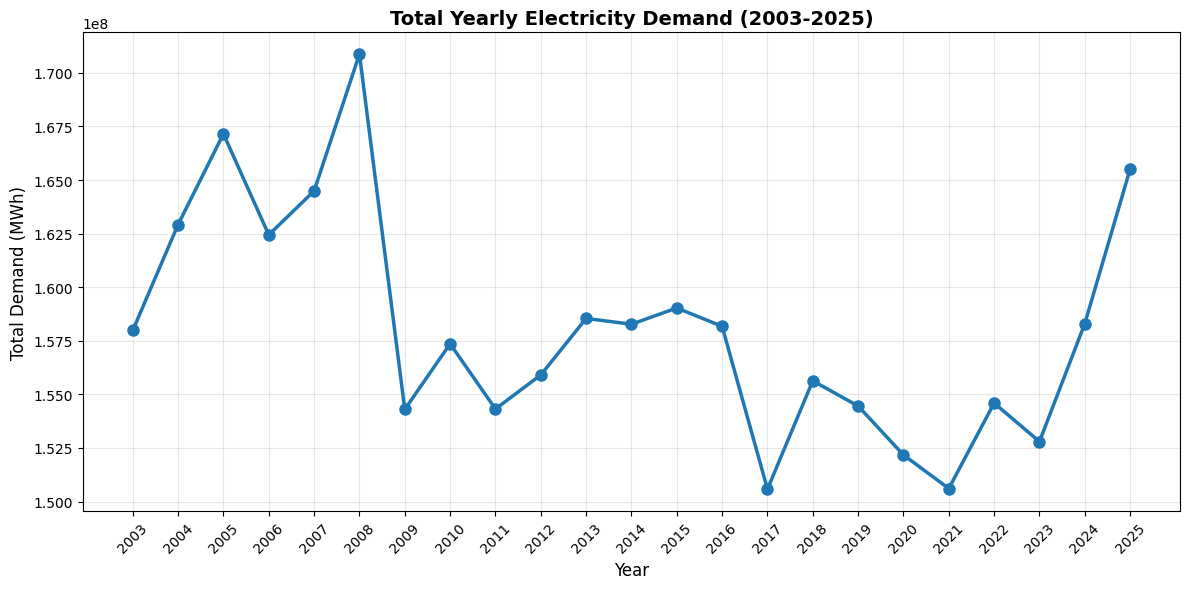

In [ ]:
# Total Yearly Demand - Line Graph (excluding 2002 and 2026)
yearly_totals = yearly_stats[(yearly_stats['Year'] != '2002') & (yearly_stats['Year'] != '2026')].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(yearly_totals))
ax.plot(x, yearly_totals['Sum'], marker='o', linewidth=2.5, markersize=8, color='#1f77b4')
ax.set_title('Total Yearly Electricity Demand (2003-2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Total Demand (MWh)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(yearly_totals['Year'], rotation=45)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./data/yearly_demand_total.png', dpi=300, bbox_inches='tight')
print(f"✓ Saved to: ./data/yearly_demand_total.png")
plt.show()